In [1]:
import gymnasium as gym
import numpy as np
import pygame
import matplotlib.pyplot as plt

In [2]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.choice(len(Q[state]))
    else:
        candidate = np.flatnonzero(Q[state] == np.max(Q[state]))
        action = np.random.choice(candidate)
    return action

In [3]:
def sarsa_update(Q, S, A, R_next, S_next, A_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * (R_next + discount_factor * Q[S_next][A_next] - Q[S][A])
    return Q[S][A]

In [4]:
def q_update(Q, S, A, R_next, S_next, discount_factor, learning_rate):
    Q[S][A] = Q[S][A] + learning_rate * (R_next + discount_factor * np.max(Q[S_next]) - Q[S][A])
    return Q[S][A]

In [5]:
def run_gym_environment_SARSA(env, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num):
    #initialize environment seed
    np.random.seed(seed_num)
    #initialize Q-table
    nA = env.action_space.n
    nS = env.observation_space.n
    Q = np.zeros((nS, nA), dtype = float )
    #Store episode history
    total_return_list = []
    Q_table_history = []
    episode_action_ratio = []
    greedy_policy_history = []

    # Main Episodes loop
    for _ in range(episodes):
        total_return = 0
        #算每個動作個數
        episode_action_count = np.zeros((nS, nA))
        #initialize state, action
        current_state, info = env.reset(seed = seed_num)
        current_action = policy(Q, current_state, epsilon)

        #Main steps loop per episode (Interact with Environment)
        for t in range(steps):
            episode_action_count[current_state, current_action] += 1 #3
            #interact with env
            next_state, reward, terminated, truncated, info = env.step(current_action)
            #---------------------------------------------------------------------------------
            # total_return += (discount_factor**t) * reward #1
            total_return += reward 
            #---------------------------------------------------------------------------------
            if terminated or truncated:
                Q[current_state, current_action] += learning_rate * (reward - Q[current_state, current_action])
                break
            next_action = policy(Q, next_state, epsilon)
            
            # Main update algorithm
            sarsa_update(Q, current_state, current_action, reward, next_state, next_action, discount_factor, learning_rate)
            # update state,action
            current_state = next_state
            current_action = next_action
        #1
        total_return_list.append(total_return)
        #2
        Q_table_history.append(Q.copy())
        #3
        row_sum = episode_action_count.sum(axis=1, keepdims=True)
        ratio = np.divide(episode_action_count,row_sum,out=np.zeros_like(episode_action_count),where=row_sum != 0)
        episode_action_ratio.append(ratio)
         #4
        greedy_policy = np.argmax(Q, axis=1)   # shape = (num_states,)
        greedy_policy_history.append(greedy_policy)

    return Q, total_return_list, Q_table_history, episode_action_ratio, greedy_policy_history

In [6]:
def run_gym_environment_QL(env, policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num):
    #initialize environment seed
    np.random.seed(seed_num)
    #initialize Q-table
    nA = env.action_space.n
    nS = env.observation_space.n
    Q = np.zeros((nS, nA), dtype = float )
    #Store episode history
    total_return_list = []
    Q_table_history = []
    episode_action_ratio = []
    greedy_policy_history = []

    # Main Episodes loop
    for _ in range(episodes):
        total_return = 0
        #算每個動作個數
        episode_action_count = np.zeros((nS, nA))
        #initialize state, action
        current_state, info = env.reset(seed = seed_num)
        current_action = policy(Q, current_state, epsilon)

        #Main steps loop per episode (Interact with Environment)
        for t in range(steps):
            episode_action_count[current_state, current_action] += 1 #3
            #interact with env
            next_state, reward, terminated, truncated, info = env.step(current_action)
            #---------------------------------------------------------------------------------
            # total_return += (discount_factor**t) * reward #1
            total_return += reward 
            #---------------------------------------------------------------------------------
            if terminated or truncated:
                Q[current_state, current_action] += learning_rate * (reward - Q[current_state, current_action])
                break
            next_action = policy(Q, next_state, epsilon)
            
            # Main update algorithm
            q_update(Q, current_state, current_action, reward, next_state, discount_factor, learning_rate)
            # update state,action
            current_state = next_state
            current_action = next_action
        #1
        total_return_list.append(total_return)
        #2
        Q_table_history.append(Q.copy())
        #3
        row_sum = episode_action_count.sum(axis=1, keepdims=True)
        ratio = np.divide(episode_action_count,row_sum,out=np.zeros_like(episode_action_count),where=row_sum != 0)
        episode_action_ratio.append(ratio)
         #4
        greedy_policy = np.argmax(Q, axis=1)   # shape = (num_states,)
        greedy_policy_history.append(greedy_policy)

    return Q, total_return_list, Q_table_history, episode_action_ratio, greedy_policy_history

In [12]:
episodes = 100
steps = 100
learning_rate = 0.1
discount_factor = 1
epsilon = 0.1
policy = epsilon_greedy

In [13]:
# store all seed Q-table 
all_returns_SARSA = []
all_returns_QL = []
# all_ratio_SARSA = []
# all_ratio_QL = []
# all_greedy_SARSA = []
# all_greedy_QL = []

for seed_num in range(1,6):

    env_sarsa = gym.make("CliffWalking-v1",render_mode = "ansi")
    env_ql = gym.make("CliffWalking-v1",render_mode = "ansi")

    Q_SARSA, total_return_list_SARSA, _, _, _ = run_gym_environment_SARSA(env_sarsa , policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)
    Q_QL, total_return_list_QL, _, _, _ = run_gym_environment_QL(env_ql , policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)

    all_returns_SARSA.append(total_return_list_SARSA)
    all_returns_QL.append(total_return_list_QL)
    # all_ratio_SARSA.append(ratio_SARSA)
    # all_ratio_QL.append(ratio_QL)
    # all_greedy_SARSA.append(greedy_policy_history_SARSA)
    # all_greedy_QL.append(greedy_policy_history_QL)

In [14]:
all_returns_SARSA = np.array(all_returns_SARSA)
all_returns_QL = np.array(all_returns_QL)
# all_ratio_SARSA = np.array(all_ratio_SARSA)
# all_ratio_QL = np.array(all_ratio_QL)
# all_greedy_SARSA = np.array(all_greedy_SARSA)
# all_greedy_QL = np.array(all_greedy_QL)

# num_seeds_s, num_episodes_s, num_states_s = all_greedy_SARSA.shape
# num_seeds_q, num_episodes_q, num_states_q = all_greedy_QL.shape
# num_actions = 4
# greedy_onehot_SARSA = np.zeros((num_seeds_s, num_episodes_s, num_states_s, num_actions))
# greedy_onehot_QL = np.zeros((num_seeds_q, num_episodes_q, num_states_q, num_actions))

# for seed in range(num_seeds_s):
#     for ep in range(num_episodes_s):
#         for s in range(num_states_s):
#             a = all_greedy_SARSA[seed, ep, s]
#             greedy_onehot_SARSA[seed, ep, s, a] = 1

# for seed in range(num_seeds_q):
#     for ep in range(num_episodes_q):
#         for s in range(num_states_q):
#             a = all_greedy_QL[seed, ep, s]
#             greedy_onehot_QL[seed, ep, s, a] = 1

print(np.shape(all_returns_SARSA))
print(np.shape(all_returns_QL))
# print(np.shape(all_ratio_SARSA))
# print(np.shape(all_ratio_QL))
# print(np.shape(greedy_onehot_SARSA))
# print(np.shape(greedy_onehot_QL))

(5, 100)
(5, 100)


In [15]:
def ci95(data):
    mean = data.mean(axis=0)
    std = data.std(axis=0, ddof=1)
    se = std/np.sqrt(data.shape[0])
    ci = 1.96*se
    return mean, ci

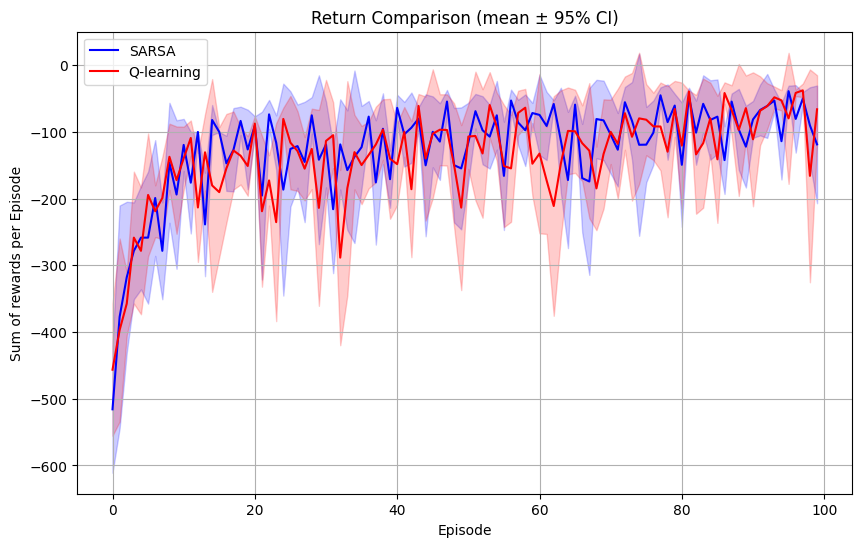

In [16]:
mean_sarsa, ci_sarsa = ci95(all_returns_SARSA)
mean_ql, ci_ql = ci95(all_returns_QL)

episodes = len(mean_sarsa)
x = np.arange(episodes)

plt.figure(figsize=(10,6))

# SARSA
plt.plot(x, mean_sarsa, label="SARSA", color="blue")
plt.fill_between(x, mean_sarsa - ci_sarsa, mean_sarsa + ci_sarsa, alpha=0.2, color="blue")

# Q-learning
plt.plot(x, mean_ql, label="Q-learning", color="red")
plt.fill_between(x, mean_ql - ci_ql, mean_ql + ci_ql, alpha=0.2, color="red")

plt.xlabel("Episode")
plt.ylabel("Sum of rewards per Episode")
plt.title("Return Comparison (mean ± 95% CI)")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
average_mean_ql = np.mean(mean_ql[-8000:-1])
print(average_mean_ql)
average_mean_sarsa = np.mean(mean_sarsa[-8000:-1])
print(average_mean_sarsa)

-136.34949494949493
-124.42828282828282


In [26]:
seed_num = 42
env_sarsa = gym.make("CliffWalking-v1",render_mode = "ansi")
env_ql = gym.make("CliffWalking-v1",render_mode = "ansi")

episodes = 1000
steps = 100
learning_rate = 0.1
discount_factor = 1
epsilon = 0.1
policy = epsilon_greedy

Q_SARSA_show, total_return_list_SARSA, _, _, _= run_gym_environment_SARSA(env_sarsa , policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)
Q_QL_show, total_return_list_QL, _, _, _ = run_gym_environment_QL(env_ql , policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)

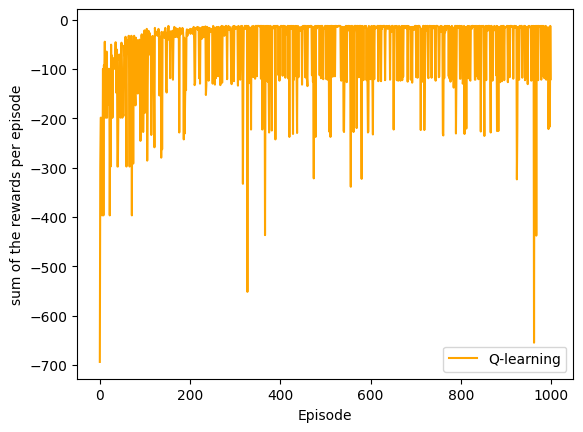

In [27]:
plt.plot(total_return_list_QL, label="Q-learning", color= "orange")
plt.xlabel("Episode")
plt.ylabel("sum of the rewards per episode")
plt.legend()
plt.show()

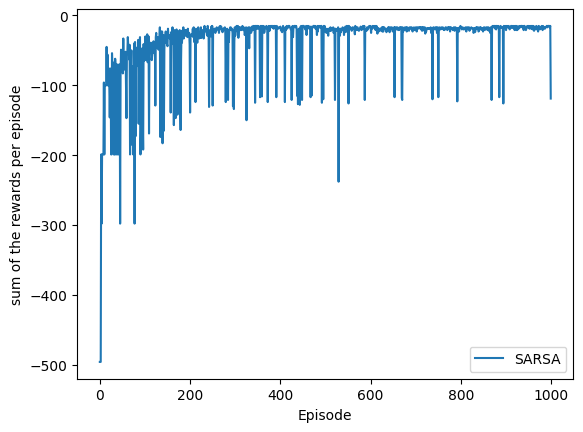

In [28]:
plt.plot(total_return_list_SARSA, label="SARSA")
plt.xlabel("Episode")
plt.ylabel("sum of the rewards per episode")
plt.legend()
plt.show()

In [29]:
env_show = gym.make("CliffWalking-v1",render_mode = "human")

state, info = env_show.reset(seed = seed_num)
done = False

while not done:
    action = np.argmax(Q_SARSA_show[state])   # greedy action
    state, reward, terminated, truncated, info = env_show.step(action)
    done = terminated or truncated

env_show.close()

In [30]:
env_show = gym.make("CliffWalking-v1",render_mode = "human")

state, info = env_show.reset(seed = seed_num)
done = False

while not done:
    action = np.argmax(Q_QL_show[state])   # greedy action
    state, reward, terminated, truncated, info = env_show.step(action)
    done = terminated or truncated

env_show.close()

In [45]:
seed_num = 42
Taxi_sarsa = gym.make("Taxi-v3")
Taxi_ql = gym.make("Taxi-v3")

episodes = 1000
steps = 100
learning_rate = 0.1
discount_factor = 1
epsilon = 0.1
policy = epsilon_greedy

Q_SARSA_show, total_return_list_SARSA, _, _, _= run_gym_environment_SARSA(env_sarsa , policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)
Q_QL_show, total_return_list_QL, _, _, _ = run_gym_environment_QL(env_ql , policy, epsilon, steps, episodes, learning_rate, discount_factor, seed_num)

In [51]:
Taxi_show = gym.make("Taxi-v3",render_mode = "human")

state, info = Taxi_show.reset(seed = seed_num)
done = False

while not done:
    action = np.argmax(Q_QL_show[state])   # greedy action
    state, reward, terminated, truncated, info = Taxi_show.step(action)
    done = terminated or truncated

env_show.close()

In [50]:
Taxi_show = gym.make("Taxi-v3",render_mode = "human")

state, info = Taxi_show.reset(seed = seed_num)
done = False

while not done:
    action = np.argmax(Q_SARSA_show[state])   # greedy action
    state, reward, terminated, truncated, info = Taxi_show.step(action)
    done = terminated or truncated

env_show.close()